# a7 - Churn prediction that helps
learn-customer-retention-with-phoebe - by Phoebe Fu

The only rule that matters: the FEATURE window must end strictly before the LABEL window begins.
We freeze a cutoff 90 days before the snapshot, build features from what was knowable AT the
cutoff, and label churn as "no orders in the 90 days after the cutoff". Then we deliberately
commit the classic leak and watch the metric lie to us.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, roc_auc_score,
                             precision_recall_curve, average_precision_score)
import xgboost as xgb

orders = pd.read_csv(ROOT / "data" / "ecommerce_orders.csv", parse_dates=["order_date"])
snapshot = orders["order_date"].max() + pd.Timedelta(days=1)
cutoff = snapshot - pd.Timedelta(days=90)
print(f"snapshot {snapshot.date()} | cutoff {cutoff.date()} | label window = the 90d after cutoff")

pre = orders[orders["order_date"] < cutoff]
post_ids = set(orders.loc[(orders["order_date"] >= cutoff)
                          & (orders["order_date"] < snapshot), "customer_id"])

g = pre.groupby("customer_id")
X = pd.DataFrame({
    "tenure_at_cutoff": (cutoff - g["order_date"].min()).dt.days,
    "order_count": g["order_date"].count(),
    "mean_order_value": g["order_value"].mean(),
    "days_since_last_at_cutoff": (cutoff - g["order_date"].max()).dt.days,
    "orders_last_60d": pre[pre["order_date"] >= cutoff - pd.Timedelta(days=60)]
                        .groupby("customer_id").size().reindex(g.size().index).fillna(0)})
y = (~X.index.isin(post_ids)).astype(int)  # 1 = churned (no orders in the 90d after cutoff)
print(f"{len(X):,} customers with pre-cutoff history, churn rate = {y.mean():.1%}")
X.describe().round(1)

snapshot 2026-07-29 | cutoff 2026-04-30 | label window = the 90d after cutoff
3,704 customers with pre-cutoff history, churn rate = 67.9%


,tenure_at_cutoff,order_count,mean_order_value,days_since_last_at_cutoff,orders_last_60d
count,"3,704.000","3,704.000","3,704.000","3,704.000","3,704.000"
mean,168.900,3.700,42.300,105.600,0.900
std,97.500,4.400,25.400,96.400,1.300
min,2.000,1.000,4.100,2.000,0.000
25%,83.000,1.000,29.600,20.000,0.000
50%,169.000,2.000,38.000,71.000,0.000
75%,256.000,5.000,48.000,179.000,2.000
max,333.000,47.000,271.500,333.000,10.000


In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)

logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
logit.fit(X_tr, y_tr)
p_logit = logit.predict_proba(X_te)[:, 1]
auc_logit = roc_auc_score(y_te, p_logit)
print(f"logistic baseline  AUC = {auc_logit:.3f}, AP = {average_precision_score(y_te, p_logit):.3f}")

model = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9,
                          eval_metric="logloss", random_state=42)
model.fit(X_tr, y_tr)
p_xgb = model.predict_proba(X_te)[:, 1]
auc_xgb = roc_auc_score(y_te, p_xgb)
print(f"xgboost            AUC = {auc_xgb:.3f}, AP = {average_precision_score(y_te, p_xgb):.3f}")
print()
print(classification_report(y_te, (p_xgb >= 0.5).astype(int),
                            target_names=["stayed", "churned"]))

logistic baseline  AUC = 0.927, AP = 0.970
xgboost            AUC = 0.929, AP = 0.970

              precision    recall  f1-score   support

      stayed       0.75      0.83      0.79       298
     churned       0.91      0.87      0.89       628

    accuracy                           0.86       926
   macro avg       0.83      0.85      0.84       926
weighted avg       0.86      0.86      0.86       926



## Precision-recall, not accuracy

With imbalanced classes and an intervention budget, the PR curve is the decision tool: pick the
threshold where the cost of a discount to a false positive balances the value of a save.

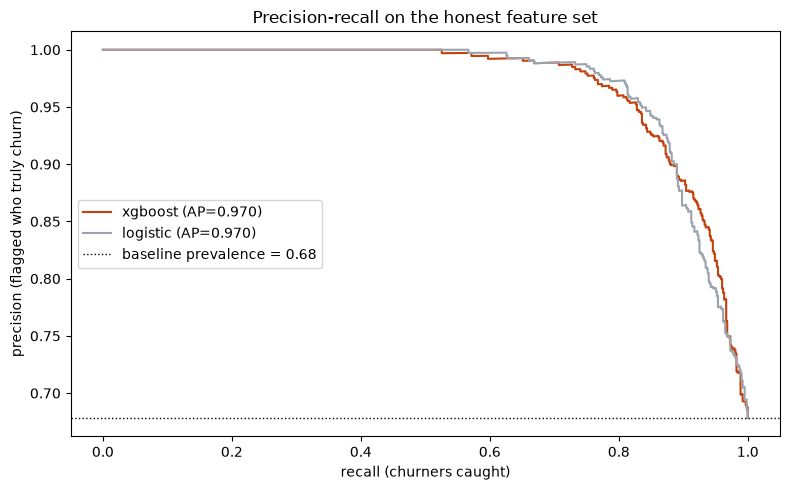

In [3]:
prec, rec, _ = precision_recall_curve(y_te, p_xgb)
prec_l, rec_l, _ = precision_recall_curve(y_te, p_logit)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(rec, prec, color="#C2410C", label=f"xgboost (AP={average_precision_score(y_te, p_xgb):.3f})")
ax.plot(rec_l, prec_l, color="#9CA3AF", label=f"logistic (AP={average_precision_score(y_te, p_logit):.3f})")
ax.axhline(y_te.mean(), color="black", linestyle=":", linewidth=1,
           label=f"baseline prevalence = {y_te.mean():.2f}")
ax.set_xlabel("recall (churners caught)")
ax.set_ylabel("precision (flagged who truly churn)")
ax.set_title("Precision-recall on the honest feature set")
ax.legend()
plt.tight_layout()
plt.show()

## What drives the prediction (SHAP)

Mean absolute SHAP value per feature = how much each feature moves predictions on average. If
TreeExplainer disagrees with this xgboost build, the fallback uses xgboost's own
`pred_contribs=True`, which returns the same tree SHAP values.

SHAP values via: xgboost pred_contribs fallback (ValueError)


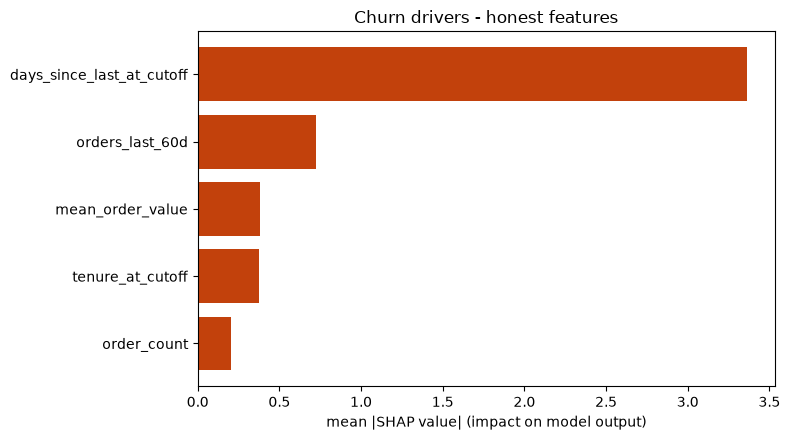

In [4]:
import shap
feature_names = list(X_te.columns)
try:
    explainer = shap.TreeExplainer(model)
    shap_vals = np.asarray(explainer.shap_values(X_te))
    source = "shap.TreeExplainer"
except Exception as e:
    dm = xgb.DMatrix(X_te, feature_names=feature_names)
    contribs = model.get_booster().predict(dm, pred_contribs=True)
    shap_vals = contribs[:, :-1]  # last column is the bias term
    source = f"xgboost pred_contribs fallback ({type(e).__name__})"
print("SHAP values via:", source)

mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=feature_names).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(mean_abs.index, mean_abs.values, color="#C2410C")
ax.set_xlabel("mean |SHAP value| (impact on model output)")
ax.set_title("Churn drivers - honest features")
plt.tight_layout()
plt.show()

## The leak demo: one column from the future

`days_since_last_order_at_snapshot` is measured AT THE SNAPSHOT, i.e. it already contains the
label window: any customer whose value exceeds 90 is churned by definition. Add it, retrain,
and the AUC rockets toward 1.0. In the wild this arrives disguised - a "last activity" field
refreshed by the ETL after the cutoff, or the cancellation event itself.

In [5]:
last_overall = orders.groupby("customer_id")["order_date"].max()
X_leak = X.copy()
X_leak["days_since_last_order_at_snapshot"] = (
    (snapshot - last_overall).dt.days.reindex(X.index))

Xl_tr, Xl_te, yl_tr, yl_te = train_test_split(X_leak, y, test_size=0.25,
                                              random_state=42, stratify=y)
leaky = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                          subsample=0.9, colsample_bytree=0.9,
                          eval_metric="logloss", random_state=42)
leaky.fit(Xl_tr, yl_tr)
auc_leaky = roc_auc_score(yl_te, leaky.predict_proba(Xl_te)[:, 1])
print(f"honest xgboost AUC = {auc_xgb:.3f}")
print(f"leaky  xgboost AUC = {auc_leaky:.3f}   <- too good to be true, because it is")
print(f"AUC jump from one leaked column: +{auc_leaky - auc_xgb:.3f}")

honest xgboost AUC = 0.929
leaky  xgboost AUC = 1.000   <- too good to be true, because it is
AUC jump from one leaked column: +0.071


**WARNING - remove the leaked feature.** An AUC near 1.0 on a churn problem is not a great
model, it is a red flag: some feature already knows the label. The honest frame keeps every
feature strictly pre-cutoff; the leaked column is dropped and stays dropped.

Final caveat (Ascarza): prediction is not prevention. The highest-risk customers are often the
least persuadable; target the persuadables (uplift modeling), not just the doomed.